In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("software_free_trial_conversion_dataset.csv")

# Display the first five rows
df.head()

,user_id,age,age_group,gender,region,company_size,user_role,signup_source,trial_length_days,logins_during_trial,features_used_count,team_members_invited,support_tickets,webinar_attended,trial_satisfaction_score,days_since_last_login,converted_to_paid
0,FT0001,64,51+,Female,West,Small,Manager,Referral,21,7,5.0,12,2,No,9,23,1
1,FT0002,61,51+,Female,West,Medium,Founder,Social Media,21,47,10.0,5,2,No,3,12,1
2,FT0003,26,26-35,Female,North,Large,Developer,Paid Ad,30,30,5.0,2,4,No,8,13,0
3,FT0004,23,18-25,Female,North,Small,Analyst,Paid Ad,30,36,1.0,5,1,Yes,3,29,0
4,FT0005,31,26-35,Male,West,Small,Developer,Referral,7,11,2.0,7,4,Yes,3,23,0


In [2]:
# Dataset size (rows and columns)
df.shape

(390, 17)

In [3]:
# Column names
df.columns

Index(['user_id', 'age', 'age_group', 'gender', 'region', 'company_size',
       'user_role', 'signup_source', 'trial_length_days',
       'logins_during_trial', 'features_used_count', 'team_members_invited',
       'support_tickets', 'webinar_attended', 'trial_satisfaction_score',
       'days_since_last_login', 'converted_to_paid'],
      dtype='object')

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   390 non-null    object 
 1   age                       390 non-null    int64  
 2   age_group                 390 non-null    object 
 3   gender                    390 non-null    object 
 4   region                    390 non-null    object 
 5   company_size              390 non-null    object 
 6   user_role                 390 non-null    object 
 7   signup_source             390 non-null    object 
 8   trial_length_days         390 non-null    int64  
 9   logins_during_trial       390 non-null    int64  
 10  features_used_count       378 non-null    float64
 11  team_members_invited      390 non-null    int64  
 12  support_tickets           390 non-null    int64  
 13  webinar_attended          390 non-null    object 
 14  trial_sati

In [5]:
# Missing values per column
df.isnull().sum()

user_id                      0
age                          0
age_group                    0
gender                       0
region                       0
company_size                 0
user_role                    0
signup_source                0
trial_length_days            0
logins_during_trial          0
features_used_count         12
team_members_invited         0
support_tickets              0
webinar_attended             0
trial_satisfaction_score     0
days_since_last_login        0
converted_to_paid            0
dtype: int64

In [6]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [7]:
# Count of each conversion class
df["converted_to_paid"].value_counts()

converted_to_paid
1    252
0    138
Name: count, dtype: int64

In [8]:
# Target distribution as a percentage
df["converted_to_paid"].value_counts(normalize=True) * 100

converted_to_paid
1    64.615385
0    35.384615
Name: proportion, dtype: float64

In [9]:
# No duplicate records in this dataset, but we reset the index for safety
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (390, 17)


In [10]:
# Define the target variable
y = df["converted_to_paid"]

# Keep the group / sensitive columns aside for later fairness analysis
fairness_columns = df[["gender", "age_group", "region"]]

# Define the input features
# Remove user_id (identifier), converted_to_paid (target), and the group columns
X = df.drop(columns=["user_id", "converted_to_paid", "gender", "age_group", "region"])

# Display the input features
X.head()

,age,company_size,user_role,signup_source,trial_length_days,logins_during_trial,features_used_count,team_members_invited,support_tickets,webinar_attended,trial_satisfaction_score,days_since_last_login
0,64,Small,Manager,Referral,21,7,5.0,12,2,No,9,23
1,61,Medium,Founder,Social Media,21,47,10.0,5,2,No,3,12
2,26,Large,Developer,Paid Ad,30,30,5.0,2,4,No,8,13
3,23,Small,Analyst,Paid Ad,30,36,1.0,5,1,Yes,3,29
4,31,Small,Developer,Referral,7,11,2.0,7,4,Yes,3,23


In [11]:
# Identify numerical and categorical feature columns
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'trial_length_days', 'logins_during_trial', 'features_used_count', 'team_members_invited', 'support_tickets', 'trial_satisfaction_score', 'days_since_last_login']
Categorical features: ['company_size', 'user_role', 'signup_source', 'webinar_attended']


In [12]:
# Fill missing numerical values with the median
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

# Fill missing categorical values with the mode
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# Confirm there are no missing values left
print("Missing values remaining:", int(X.isnull().sum().sum()))

Missing values remaining: 0


In [13]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Display the final feature set
print("Final feature set shape:", X.shape)
X.head()

Final feature set shape: (390, 20)


,age,trial_length_days,logins_during_trial,features_used_count,team_members_invited,support_tickets,trial_satisfaction_score,days_since_last_login,company_size_Medium,company_size_Small,company_size_Solo,user_role_Developer,user_role_Founder,user_role_Manager,user_role_Student,signup_source_Paid Ad,signup_source_Referral,signup_source_Social Media,signup_source_University,webinar_attended_Yes
0,64,21,7,5.0,12,2,9,23,False,True,False,False,False,True,False,False,True,False,False,False
1,61,21,47,10.0,5,2,3,12,True,False,False,False,True,False,False,False,False,True,False,False
2,26,30,30,5.0,2,4,8,13,False,False,False,True,False,False,False,True,False,False,False,False
3,23,30,36,1.0,5,1,3,29,False,True,False,False,False,False,False,True,False,False,False,True
4,31,7,11,2.0,7,4,3,23,False,True,False,True,False,False,False,False,True,False,False,True


In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We keep the fairness columns aligned with the same split for later analysis
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the size of each set
print("Training set size:", X_train.shape[0], "users")
print("Testing set size: ", X_test.shape[0], "users")
print("Number of features:", X_train.shape[1])

Training set size: 312 users
Testing set size:  78 users
Number of features: 20


In [15]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# Use the trained model to predict conversion on the test data
y_pred = model.predict(X_test)

# Compare actual and predicted values for the first 10 test users
comparison = pd.DataFrame({
    "Actual Converted": y_test.values,
    "Predicted Converted": y_pred
})
comparison.head(10)

,Actual Converted,Predicted Converted
0,1,1
1,1,1
2,0,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,0
9,0,0


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the four evaluation metrics on the test data
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the metrics in a table
metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})
metrics_results.round(4)

,Metric,Score
0,Accuracy,0.7692
1,Precision,0.8333
2,Recall,0.8000
3,F1-Score,0.8163


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract the four values
tn, fp, fn, tp = cm.ravel()

# Show the confusion matrix as a labelled table
cm_table = pd.DataFrame(
    cm,
    index=["Actual Not Converted (0)", "Actual Converted (1)"],
    columns=["Predicted Not Converted (0)", "Predicted Converted (1)"]
)
cm_table

,Predicted Not Converted (0),Predicted Converted (1)
Actual Not Converted (0),20,8
Actual Converted (1),10,40


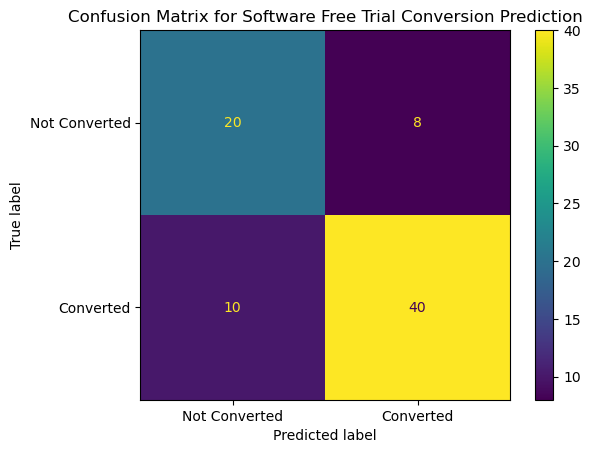

In [19]:
# Visualize the confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Converted", "Converted"])
display.plot()
plt.title("Confusion Matrix for Software Free Trial Conversion Prediction")
plt.show()

In [20]:
# Summary table of the four confusion matrix values
confusion_summary = pd.DataFrame({
    "Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Meaning": [
        "Correctly predicted the user did not convert",
        "Predicted conversion, but the user did not convert",
        "Predicted no conversion, but the user actually converted",
        "Correctly predicted the user converted"
    ],
    "Value": [tn, fp, fn, tp]
})
confusion_summary

,Type,Meaning,Value
0,True Negative,Correctly predicted the user did not convert,20
1,False Positive,"Predicted conversion, but the user did not con...",8
2,False Negative,"Predicted no conversion, but the user actually...",10
3,True Positive,Correctly predicted the user converted,40


In [21]:
# Build an error analysis table
error_analysis = pd.DataFrame({
    "User ID": df.loc[y_test.index, "user_id"].values,
    "Actual Converted": y_test.values,
    "Predicted Converted": y_pred
})

# Mark whether each prediction is correct
error_analysis["Correct Prediction"] = error_analysis["Actual Converted"] == error_analysis["Predicted Converted"]
error_analysis.head(10)

,User ID,Actual Converted,Predicted Converted,Correct Prediction
0,FT0224,1,1,True
1,FT0329,1,1,True
2,FT0228,0,1,False
3,FT0143,1,1,True
4,FT0058,1,1,True
5,FT0257,1,1,True
6,FT0122,1,1,True
7,FT0041,1,1,True
8,FT0284,1,0,False
9,FT0221,0,0,True


In [22]:
# Classify each prediction into one of the four error types
def classify_error(row):
    if row["Actual Converted"] == 0 and row["Predicted Converted"] == 0:
        return "True Negative"
    elif row["Actual Converted"] == 0 and row["Predicted Converted"] == 1:
        return "False Positive"
    elif row["Actual Converted"] == 1 and row["Predicted Converted"] == 0:
        return "False Negative"
    else:
        return "True Positive"

error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)
error_analysis.head(10)

,User ID,Actual Converted,Predicted Converted,Correct Prediction,Error Type
0,FT0224,1,1,True,True Positive
1,FT0329,1,1,True,True Positive
2,FT0228,0,1,False,False Positive
3,FT0143,1,1,True,True Positive
4,FT0058,1,1,True,True Positive
5,FT0257,1,1,True,True Positive
6,FT0122,1,1,True,True Positive
7,FT0041,1,1,True,True Positive
8,FT0284,1,0,False,False Negative
9,FT0221,0,0,True,True Negative


In [23]:
# Count how many times each error type appears
error_counts = error_analysis["Error Type"].value_counts().reset_index()
error_counts.columns = ["Error Type", "Count"]
error_counts

,Error Type,Count
0,True Positive,40
1,True Negative,20
2,False Negative,10
3,False Positive,8


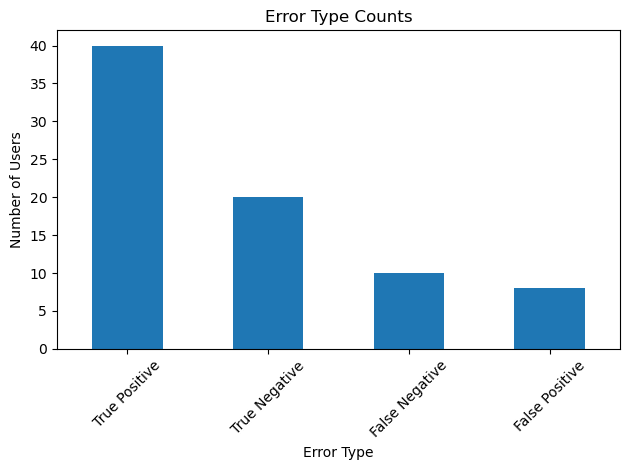

In [24]:
# Visualize the error type counts
error_counts.plot(x="Error Type", y="Count", kind="bar", legend=False)
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Show only the wrong predictions
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]
wrong_predictions.head(10)

,User ID,Actual Converted,Predicted Converted,Correct Prediction,Error Type
2,FT0228,0,1,False,False Positive
8,FT0284,1,0,False,False Negative
11,FT0355,1,0,False,False Negative
28,FT0095,1,0,False,False Negative
29,FT0090,1,0,False,False Negative
33,FT0077,0,1,False,False Positive
36,FT0042,1,0,False,False Negative
39,FT0304,0,1,False,False Positive
43,FT0001,1,0,False,False Negative
44,FT0256,1,0,False,False Negative


In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Create a 5-fold cross-validation strategy that keeps the conversion balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation using accuracy
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# Show the accuracy for each fold
cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})
cv_results.round(4)

,Fold,Accuracy
0,Fold 1,0.7436
1,Fold 2,0.7436
2,Fold 3,0.7436
3,Fold 4,0.7051
4,Fold 5,0.7436


In [27]:
# Mean and standard deviation of the cross-validation scores
cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value": [cv_scores.mean(), cv_scores.std()]
})
cv_summary.round(4)

,Metric,Value
0,Mean Cross-Validation Accuracy,0.7359
1,Standard Deviation,0.0154


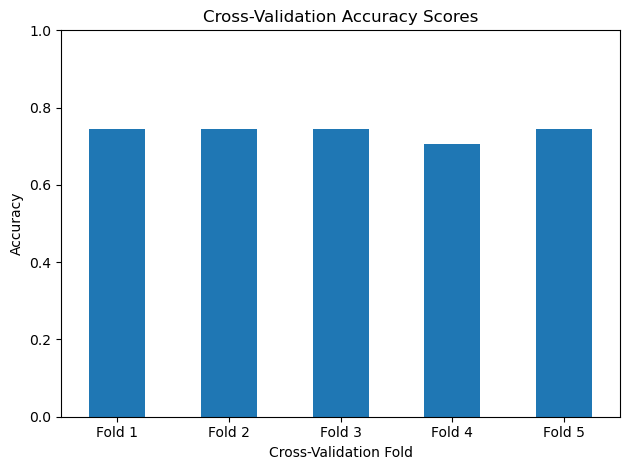

In [28]:
# Visualize the cross-validation accuracy scores
cv_results.plot(x="Fold", y="Accuracy", kind="bar", legend=False)
plt.title("Cross-Validation Accuracy Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# Compare training and testing accuracy for the current model
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

overfitting_check = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})
overfitting_check.round(4)

,Dataset,Accuracy
0,Training Data,0.8718
1,Testing Data,0.7692


In [30]:
# Test different tree depths from 1 to 10
depth_results = []
for depth in range(1, 11):
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, temp_model.predict(X_train))
    test_acc = accuracy_score(y_test, temp_model.predict(X_test))
    depth_results.append([depth, train_acc, test_acc])

depth_results_df = pd.DataFrame(depth_results, columns=["Max Depth", "Training Accuracy", "Testing Accuracy"])
depth_results_df.round(4)

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.6923,0.6026
1,2,0.7628,0.6410
2,3,0.8013,0.7692
3,4,0.8718,0.7692
4,5,0.9167,0.7692
5,6,0.9551,0.7564
6,7,0.9872,0.7436
7,8,1.0000,0.7436
8,9,1.0000,0.7436
9,10,1.0000,0.7436


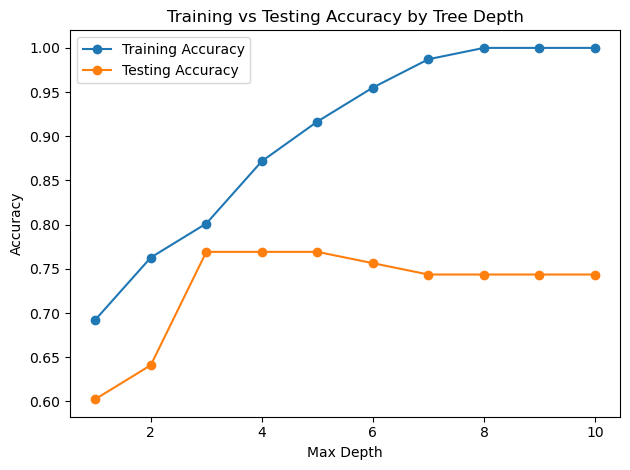

In [31]:
# Visualize training vs testing accuracy across tree depths
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")
plt.title("Training vs Testing Accuracy by Tree Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Get feature importance from the trained model
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance_df

,Feature,Importance
0,days_since_last_login,0.256584
1,logins_during_trial,0.244518
2,features_used_count,0.243452
3,team_members_invited,0.134023
4,trial_satisfaction_score,0.088952
5,age,0.032471
6,user_role_Manager,0.000000
7,signup_source_University,0.000000
8,signup_source_Social Media,0.000000
9,signup_source_Referral,0.000000


In [33]:
# Select the top 10 most important features
top_features = feature_importance_df.head(10)
top_features

,Feature,Importance
0,days_since_last_login,0.256584
1,logins_during_trial,0.244518
2,features_used_count,0.243452
3,team_members_invited,0.134023
4,trial_satisfaction_score,0.088952
5,age,0.032471
6,user_role_Manager,0.000000
7,signup_source_University,0.000000
8,signup_source_Social Media,0.000000
9,signup_source_Referral,0.000000


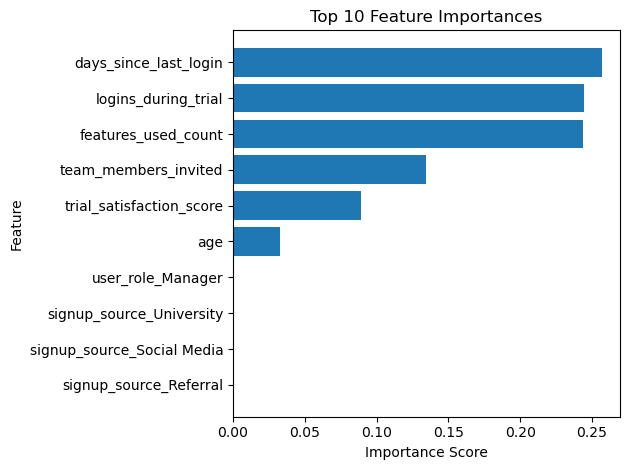

In [34]:
# Visualize the top 10 important features
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
!pip install -q shap

In [36]:
import shap

# Initialize SHAP JavaScript visualization
shap.initjs()

# Create a SHAP explainer for the trained Decision Tree
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)
type(shap_values)

numpy.ndarray

In [37]:
# Different SHAP versions return different formats; select the converted class (class 1)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
    base_value_class1 = explainer.expected_value[1]
else:
    shap_values_class1 = shap_values[:, :, 1]
    base_value_class1 = explainer.expected_value[1]

shap_values_class1.shape

(78, 20)

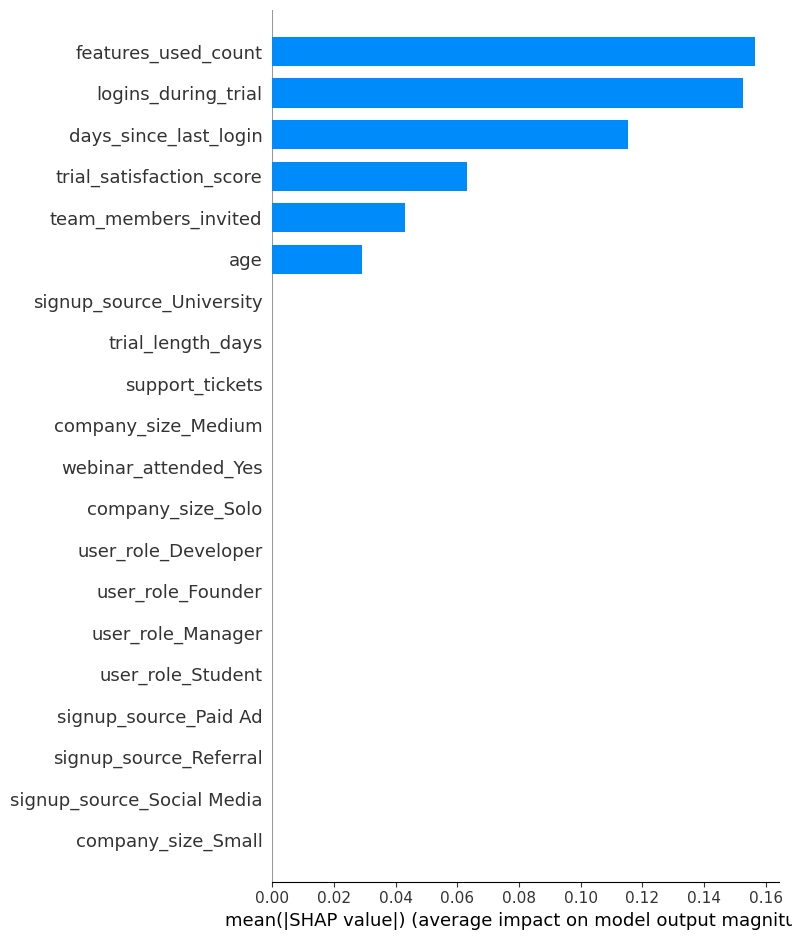

In [38]:
# SHAP summary bar plot (global view)
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

In [39]:
# Explain one individual user
customer_index = 0
customer_data = X_test.iloc[customer_index]
customer_shap_values = shap_values_class1[customer_index]

customer_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": customer_data.values,
    "SHAP Value": customer_shap_values
})
customer_explanation["Absolute SHAP Value"] = customer_explanation["SHAP Value"].abs()
customer_explanation = customer_explanation.sort_values(by="Absolute SHAP Value", ascending=False)
customer_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
2,logins_during_trial,23,0.100725,0.100725
7,days_since_last_login,7,0.088618,0.088618
3,features_used_count,16.0,0.077977,0.077977
4,team_members_invited,12,0.031647,0.031647
6,trial_satisfaction_score,5,0.017201,0.017201
0,age,57,0.004816,0.004816
13,user_role_Manager,True,0.000000,0.000000
18,signup_source_University,False,0.000000,0.000000
17,signup_source_Social Media,False,0.000000,0.000000
16,signup_source_Referral,False,0.000000,0.000000


In [40]:
# Actual and predicted conversion for this user
single_user_result = pd.DataFrame({
    "Actual Converted": [y_test.iloc[customer_index]],
    "Predicted Converted": [y_pred[customer_index]]
})
single_user_result

,Actual Converted,Predicted Converted
0,1,1


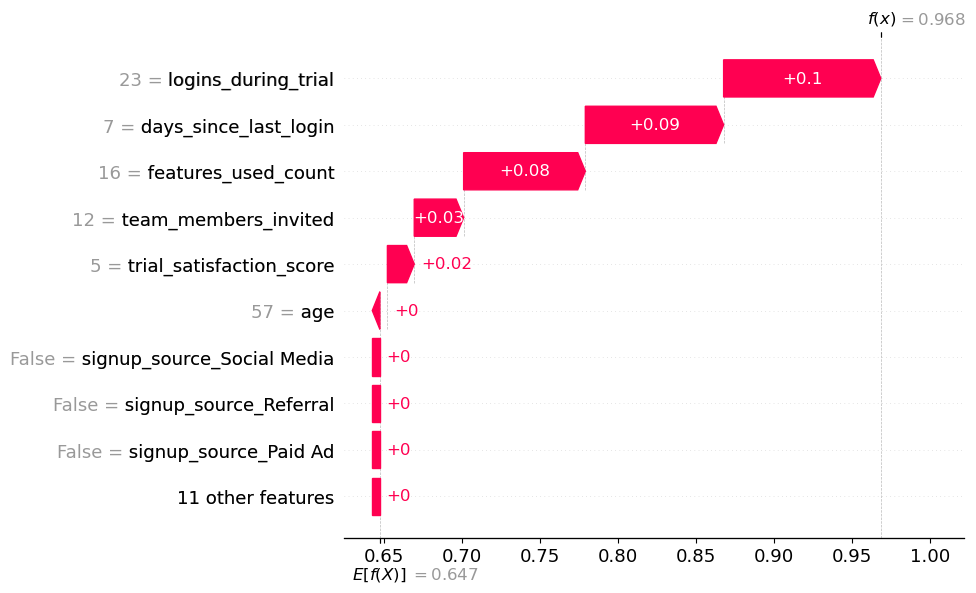

In [41]:
# SHAP waterfall plot for this one user
single_user_explanation = shap.Explanation(
    values=customer_shap_values,
    base_values=base_value_class1,
    data=customer_data,
    feature_names=X_test.columns
)
shap.plots.waterfall(single_user_explanation)

In [42]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=429082ebffdb519af7c0d8604df48f566f5c35866cbe6b4fc00fa4d64dc5b181
  Stored in directory: c:\users\asus\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [43]:
from lime.lime_tabular import LimeTabularExplainer

# Prepare data for LIME (numeric arrays)
X_train_lime = X_train.astype(float)
X_test_lime = X_test.astype(float)
feature_names = X_train_lime.columns.tolist()
class_names = ["Not Converted", "Converted"]

# Create the LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

In [44]:
# Explain one user (the same first test user)
customer_index = 0
customer_instance = X_test_lime.iloc[customer_index]

lime_explanation = lime_explainer.explain_instance(
    data_row=customer_instance.values,
    predict_fn=model.predict_proba,
    num_features=10
)

# Show the prediction probabilities for this user
predicted_probabilities = model.predict_proba(X_test_lime.iloc[[customer_index]])[0]
lime_prediction_result = pd.DataFrame({
    "Actual Converted": [y_test.iloc[customer_index]],
    "Predicted Converted": [model.predict(X_test_lime.iloc[[customer_index]])[0]],
    "Probability of Not Converted": [predicted_probabilities[0]],
    "Probability of Converted": [predicted_probabilities[1]]
})
lime_prediction_result.round(4)

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Actual Converted,Predicted Converted,Probability of Not Converted,Probability of Converted
0,1,1,0.0316,0.9684


In [45]:
# LIME explanation as a readable table
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)
lime_explanation_table

,Feature Condition,Contribution
0,days_since_last_login <= 8.00,0.215245
1,features_used_count > 15.00,0.178158
2,10.00 < logins_during_trial <= 25.00,-0.122317
3,team_members_invited > 9.00,0.088326
4,3.00 < trial_satisfaction_score <= 5.00,-0.036350
5,age > 56.00,0.034175
6,company_size_Solo <= 0.00,0.012838
7,signup_source_University <= 0.00,0.012505
8,support_tickets <= 2.00,-0.012488
9,user_role_Manager > 0.00,0.012299


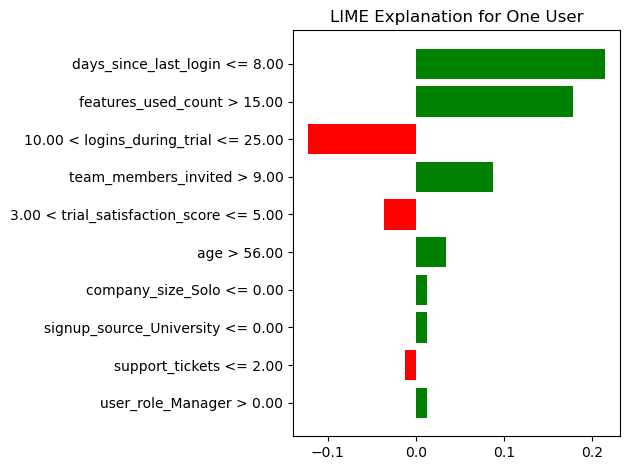

In [46]:
# LIME explanation chart
fig = lime_explanation.as_pyplot_figure()
plt.title("LIME Explanation for One User")
plt.tight_layout()
plt.show()

In [47]:
# Build a fairness table for the test users
fairness_data = df.loc[y_test.index, ["user_id", "gender", "age_group", "region"]].copy()
fairness_data["Actual Converted"] = y_test.values
fairness_data["Predicted Converted"] = y_pred
fairness_data["Correct Prediction"] = fairness_data["Actual Converted"] == fairness_data["Predicted Converted"]
fairness_data.head(10)

,user_id,gender,age_group,region,Actual Converted,Predicted Converted,Correct Prediction
223,FT0224,Female,51+,West,1,1,True
328,FT0329,Male,51+,West,1,1,True
227,FT0228,Male,36-50,West,0,1,False
142,FT0143,Male,51+,North,1,1,True
57,FT0058,Female,51+,North,1,1,True
256,FT0257,Female,18-25,North,1,1,True
121,FT0122,Male,51+,East,1,1,True
40,FT0041,Female,36-50,East,1,1,True
283,FT0284,Female,36-50,West,1,0,False
220,FT0221,Female,51+,North,0,0,True


In [48]:
# Function that summarizes model behaviour by a group column
def fairness_summary(group_column):
    summary = fairness_data.groupby(group_column).agg(
        Number_of_Users=("user_id", "count"),
        Actual_Positive_Rate=("Actual Converted", "mean"),
        Predicted_Positive_Rate=("Predicted Converted", "mean"),
        Accuracy=("Correct Prediction", "mean")
    ).reset_index()
    return summary

In [49]:
gender_fairness = fairness_summary("gender")
gender_fairness.round(3)

,gender,Number_of_Users,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,Female,41,0.683,0.610,0.780
1,Male,37,0.595,0.622,0.757


In [50]:
region_fairness = fairness_summary("region")
region_fairness.round(3)

,region,Number_of_Users,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,East,14,0.714,0.714,0.857
1,North,17,0.588,0.647,0.824
2,South,24,0.458,0.500,0.708
3,West,23,0.826,0.652,0.739


In [51]:
age_group_fairness = fairness_summary("age_group")
age_group_fairness.round(3)

,age_group,Number_of_Users,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,18-25,21,0.476,0.524,0.762
1,26-35,9,0.556,0.444,0.889
2,36-50,21,0.762,0.762,0.810
3,51+,27,0.704,0.630,0.704


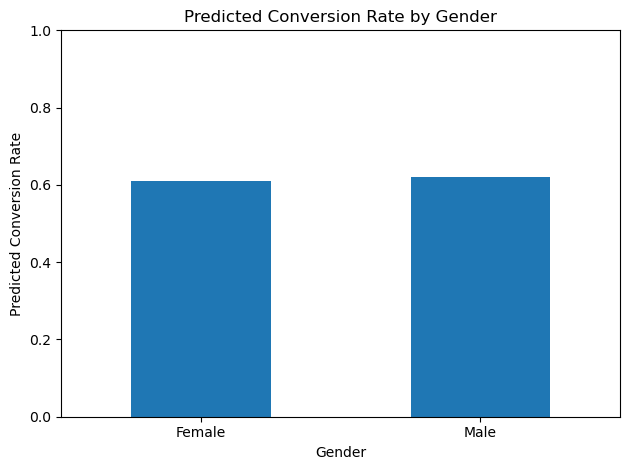

In [52]:
# Visualization: predicted conversion rate by gender
gender_fairness.plot(x="gender", y="Predicted_Positive_Rate", kind="bar", legend=False)
plt.title("Predicted Conversion Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Predicted Conversion Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

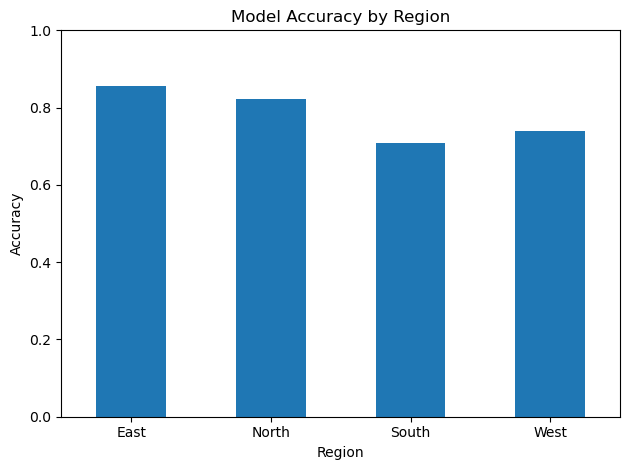

In [53]:
# Visualization: accuracy by region
region_fairness.plot(x="region", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy by Region")
plt.xlabel("Region")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
# Build a final business summary table
final_train_acc = accuracy_score(y_train, model.predict(X_train))
final_test_acc = accuracy_score(y_test, y_pred)

business_summary = pd.DataFrame({
    "Result": [
        "Training Accuracy", "Testing Accuracy", "Precision", "Recall", "F1-Score",
        "True Negative", "False Positive", "False Negative", "True Positive"
    ],
    "Value": [
        round(final_train_acc, 4), round(final_test_acc, 4), round(precision, 4),
        round(recall, 4), round(f1, 4), tn, fp, fn, tp
    ],
    "Business Meaning": [
        "How well the model learned from historical trial data",
        "How well the model works on new trial users",
        "Of predicted converters, how many actually converted",
        "Of actual converters, how many the model caught",
        "Balance between precision and recall",
        "Users correctly predicted as not converting",
        "Users wrongly predicted as converting",
        "Converters the model missed",
        "Converters the model correctly identified"
    ]
})
business_summary

,Result,Value,Business Meaning
0,Training Accuracy,0.8718,How well the model learned from historical tri...
1,Testing Accuracy,0.7692,How well the model works on new trial users
2,Precision,0.8333,"Of predicted converters, how many actually con..."
3,Recall,0.8000,"Of actual converters, how many the model caught"
4,F1-Score,0.8163,Balance between precision and recall
5,True Negative,20.0000,Users correctly predicted as not converting
6,False Positive,8.0000,Users wrongly predicted as converting
7,False Negative,10.0000,Converters the model missed
8,True Positive,40.0000,Converters the model correctly identified


In [55]:
"""
Final Business Interpretation

- **What the model predicts:** whether a software free trial user will convert to a paid subscription, using engagement, behavioural, and profile features collected during the trial period.
- **Overall performance:** solid. Testing accuracy is about 0.77, well above the ≈0.65 "predict everyone converts" baseline, and cross-validation confirms a stable mean accuracy of ≈0.74 with low variance (std ≈0.015). The model adds genuine predictive value.
- **Most important evaluation metric:** Recall, because missing a user who is ready to convert means a lost revenue opportunity. The model's recall is ≈0.80, meaning it catches about 80% of real converters, which is a strong result for a tree-depth-4 classifier on 390 records.
- **Main error types:** False Positives (8 users) and False Negatives (10 users) are nearly balanced, though reducing false negatives should be the priority to capture more revenue-ready users.
- **Business impact of errors:** false negatives mean high-intent trial users receive no targeted outreach and may convert later or not at all. False positives cause minor wasted sales or marketing effort on users who are not yet ready to commit.
- **Overfitting evidence:** training accuracy (≈0.87) exceeds testing accuracy (≈0.77) at depth 4, and the gap grows steeply at higher depths (depth 8+: train = 1.00, test ≈0.74). The model shows mild overfitting at depth 4 and strong overfitting beyond.
- **Most important features:** `days_since_last_login`, `logins_during_trial`, and `features_used_count` each contribute roughly equal importance (≈24–26% each), followed by `team_members_invited` (≈13%) and `trial_satisfaction_score` (≈9%). Engagement depth and recency are the clearest conversion signals.
- **SHAP and LIME insight:** both explainers confirm that recent, frequent, and feature-rich trial activity drives conversion predictions. For the sample user, high login count, recent activity, and many features explored all pushed the prediction confidently toward Converted, and the model was correct (True Positive, ≈97% predicted probability).
- **Fairness and bias concern:** the model under-predicts conversion for West-region users (actual ≈83%, predicted ≈65%) and slightly under-predicts for female users. Teams using the model for outreach prioritisation should be aware that some segments may receive less attention than their actual conversion intent warrants.
- **Final recommendation:** **This model is a solid early-stage tool but should not be used as the sole decision-maker.** Its precision (≈0.83) and recall (≈0.80) are respectable for a prototype, but before full deployment it should be improved by: gathering more data (especially from under-represented regions and age groups), engineering additional features (e.g. which specific features were used, session duration), addressing class imbalance more formally (class weights or SMOTE), tuning the prediction threshold based on the business's precision-recall trade-off preference, and comparing against stronger models such as Random Forest or Gradient Boosting. The model should support—not replace—human judgment in conversion outreach decisions.
"""

'\nFinal Business Interpretation\n\n- **What the model predicts:** whether a software free trial user will convert to a paid subscription, using engagement, behavioural, and profile features collected during the trial period.\n- **Overall performance:** solid. Testing accuracy is about 0.77, well above the ≈0.65 "predict everyone converts" baseline, and cross-validation confirms a stable mean accuracy of ≈0.74 with low variance (std ≈0.015). The model adds genuine predictive value.\n- **Most important evaluation metric:** Recall, because missing a user who is ready to convert means a lost revenue opportunity. The model\'s recall is ≈0.80, meaning it catches about 80% of real converters, which is a strong result for a tree-depth-4 classifier on 390 records.\n- **Main error types:** False Positives (8 users) and False Negatives (10 users) are nearly balanced, though reducing false negatives should be the priority to capture more revenue-ready users.\n- **Business impact of errors:** fals